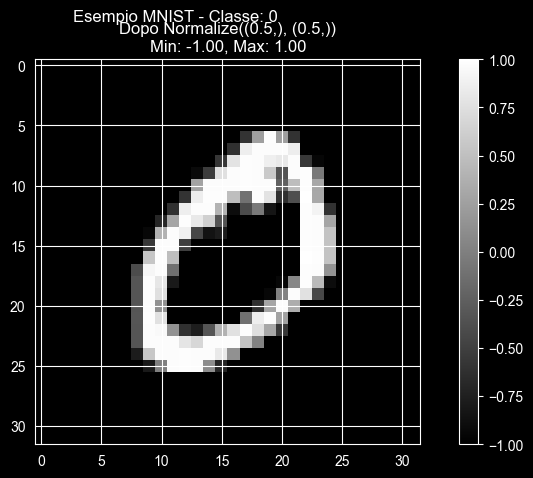

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import random_split

# Trasformazioni: LeNet-5 originale prevede input 32x32,
# MNIST è 28x28, quindi aggiungiamo del padding.
transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(), # Porta le immagini da 255 valori per pixel a [0,1]
    transforms.Normalize((0.5,), (0.5,)) #Sottrae dai pixel 0.5 e divide per 0,5 per portare o valori all'intervallo [-1,1]
])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_size = 50000
val_size = 10000
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# Creiamo i DataLoader
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

def visualizza(idx):
    img_norm, label = full_train_dataset[idx]

    fig, (ax2) = plt.subplots(1, 1, figsize=(10, 5))


    # Immagine Normalizzata (-1, 1)
    im2 = ax2.imshow(img_norm.squeeze(), cmap='gray')
    ax2.set_title(f"Dopo Normalize((0.5,), (0.5,))\nMin: {img_norm.min():.2f}, Max: {img_norm.max():.2f}")
    plt.colorbar(im2, ax=ax2)

    plt.suptitle(f"Esempio MNIST - Classe: {label}")
    plt.show()

visualizza(1)


In [27]:
for x, y in val_loader:
    print(x[0])
    print(y[0])
    break

tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])
tensor(1)


In [2]:
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval() # Imposta il modello in modalità valutazione

    with torch.no_grad(): # Disabilita il calcolo dei gradienti per risparmiare memoria
        for x, y in loader:
            scores = model(x)
            _, predictions = scores.max(1) # Otteniamo l'indice della classe con probabilità maggiore
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train() # Torna in modalità training
    return (float(num_correct) / num_samples) * 100

In [44]:
#Definisco Lenet 5
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # Layer Convoluzionale 1: 6 filtri 5x5
        self.c1 = nn.Conv2d(1, 6, kernel_size=5) #1 canale, 6 filtri di grandezza 5x5. Passo da 32x32 a 28x28
        # Layer Max Pooling 1: riduce la dimensione spaziale
        self.s2 = nn.MaxPool2d(kernel_size=2, stride=2) #passo da 28x28x6 a 14x14x6
        # Layer Convoluzionale 2: 16 filtri 5x5
        self.c3 = nn.Conv2d(6, 16, kernel_size=5) #da 6 canali a 16 filtri di grandezza 5x5. Passo 14x14x6 a 10x10x16
        # Layer Max Pooling 2
        self.s4 = nn.MaxPool2d(kernel_size=2, stride=2) #passo da 10x10x16 a 5x5x16

        # Layer completamente connessi (MLP) per la classificazione finale
        self.fc1 = nn.Linear(16 * 5 * 5, 120) #Layer con 120 neuroni
        self.fc2 = nn.Linear(120, 84) #layer con 84 neuroni
        self.fc3 = nn.Linear(84, 10) # 10 classi (cifre 0-9)

        # Funzione di attivazione: ReLU è la più utilizzata nella pratica
        self.relu = nn.ReLU()

    def forward(self, x):
        # Forward pass: PyTorch costruisce il grafo computazionale qui
        x = self.relu(self.c1(x))
        x = self.s2(x)
        x = self.relu(self.c3(x))
        x = self.s4(x)

        # Flattening per passare ai layer densi
        x = x.view(-1, 16 * 5 * 5)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = LeNet5()

In [46]:
# Loop di Training
# Definizione Loss e Ottimizzatore
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    for batch_idx, (data, targets) in enumerate(train_loader):
        # Forward pass: calcolo delle attivazioni e della loss
        scores = model(data)
        loss = criterion(scores, targets)

        # Backward pass: automatic differentiation tramite backpropagation
        optimizer.zero_grad()
        loss.backward()

        # Aggiornamento dei pesi w e b [cite: 89]
        optimizer.step()

    # Controllo accuracy alla fine di ogni epoca
    train_acc = check_accuracy(train_loader, model)
    val_acc = check_accuracy(val_loader, model)

    print(f"Epoch {epoch+1} conclusa. Loss: {loss.item():.4f}")
    print(f"Accuracy - Training: {train_acc:.2f}%, Validation: {val_acc:.2f}%")

Epoch 1 conclusa. Loss: 0.0150
Accuracy - Training: 97.63%, Validation: 97.12%
Epoch 2 conclusa. Loss: 0.0552
Accuracy - Training: 98.38%, Validation: 97.75%
Epoch 3 conclusa. Loss: 0.0877
Accuracy - Training: 98.92%, Validation: 98.22%
Epoch 4 conclusa. Loss: 0.0033
Accuracy - Training: 99.16%, Validation: 98.42%
Epoch 5 conclusa. Loss: 0.0302
Accuracy - Training: 99.26%, Validation: 98.49%


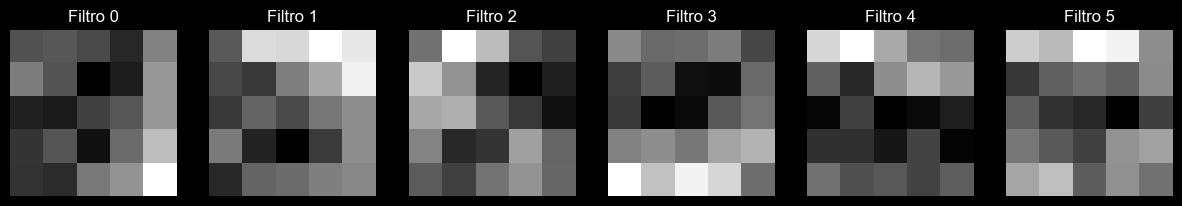

In [40]:
import matplotlib.pyplot as plt

def visualizza_filtri(model):
    # Estraiamo i pesi del primo layer convoluzionale
    filters = model.c1.weight.data.cpu().numpy()

    # Creiamo una griglia per i 6 filtri di LeNet-5
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))

    for i, ax in enumerate(axes):
        # Ogni filtro è 5x5
        filtro = filters[i][0]
        ax.imshow(filtro, cmap='gray')
        ax.set_title(f"Filtro {i}")
        ax.axis('off')

    plt.show()

visualizza_filtri(model)

In [ ]:
def visualizza_attivazioni(model, immagine):
    model.eval()
    with torch.no_grad():
        # Passiamo l'immagine nel primo layer
        attivazione_c1 = model.relu(model.c1(immagine.unsqueeze(0)))

    # Visualizziamo i 6 canali in uscita dal primo layer
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        axes[i].imshow(attivazione_c1[0, i].cpu(), cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f"Mappa {i}")

    plt.suptitle("Output del Layer C1 (Feature Maps)")
    plt.show()

# Prendi un'immagine dal test_loader e visualizzala
dataiter = iter(val_loader)
immagini, labels = next(dataiter)
visualizza_attivazioni(model, immagini[6])

Filtro di contrasto: Alcune mappe evidenzieranno solo i bordi verticali del numero, altre quelli orizzontali.

Riduzione del rumore: La rete impara a ignorare i pixel neri di sfondo e a concentrarsi solo sulla forma del numero.


Gerarchia: Se ripetessi l'operazione per il layer c3, vedresti mappe molto più astratte e rimpicciolite (a causa del pooling), dove ogni "punto" luminoso indica la presenza di una caratteristica complessa .

ora consideriamo la seconda rete: AlexNet

In [3]:
transform_alexnet = transforms.Compose([
    transforms.Resize(224),           # Ridimensiona da 28x28 a 224x224
    transforms.Grayscale(num_output_channels=3), # Converte 1 canale in 3 (R=G=B)
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carica il dataset con il nuovo transform
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_alexnet)
train_size = 50000
val_size = 10000
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# Creiamo i DataLoader
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

In [4]:
class AlexNetMNIST(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetMNIST, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNetMNIST()

In [5]:
# 1. Configurazione del Device
# Controlla se è disponibile una GPU NVIDIA (cuda) o il chip Apple Silicon (mps)
#ATTENAZIONE PER LE PROSSIME CELLE È NECESSARIA LA GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Sto usando il device: {device}")

Sto usando il device: cuda


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim



# 2. Inizializzazione Modello, Loss e Ottimizzatore
# IMPORTANTE: Sposta subito il modello sul device
model = AlexNetMNIST().to(device) # o LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Funzione per il controllo dell'accuracy (su Device)
def check_accuracy(loader, model, device):
    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Sposta i dati del validation set sul device
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train()
    return (float(num_correct) / num_samples) * 100

# 4. Ciclo di Training Completo
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0
    model.train()

    for batch_idx, (data, targets) in enumerate(train_loader):
        # Sposta immagini e labels sul device
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass
        scores = model(data)
        loss = criterion(scores, targets)

        # Backward pass (Backpropagation)
        optimizer.zero_grad() # Fondamentale per non accumulare i gradienti
        loss.backward()

        # Aggiornamento dei pesi
        optimizer.step()

        running_loss += loss.item()

    # Calcolo accuracy a fine epoca
    train_acc = check_accuracy(train_loader, model, device)
    val_acc = check_accuracy(val_loader, model, device)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss/len(train_loader):.4f}")
    print(f"Accuracy -> Training: {train_acc:.2f}%, Validation: {val_acc:.2f}%")
    print("-" * 30)

Epoch [1/5] - Loss: 0.3157
Accuracy -> Training: 96.86%, Validation: 96.86%
------------------------------
Epoch [2/5] - Loss: 0.1135
Accuracy -> Training: 98.06%, Validation: 97.95%
------------------------------
Epoch [3/5] - Loss: 0.0965
Accuracy -> Training: 97.90%, Validation: 97.73%
------------------------------
Epoch [4/5] - Loss: 0.0836
Accuracy -> Training: 98.52%, Validation: 98.41%
------------------------------
Epoch [5/5] - Loss: 0.0763
Accuracy -> Training: 98.75%, Validation: 98.43%
------------------------------


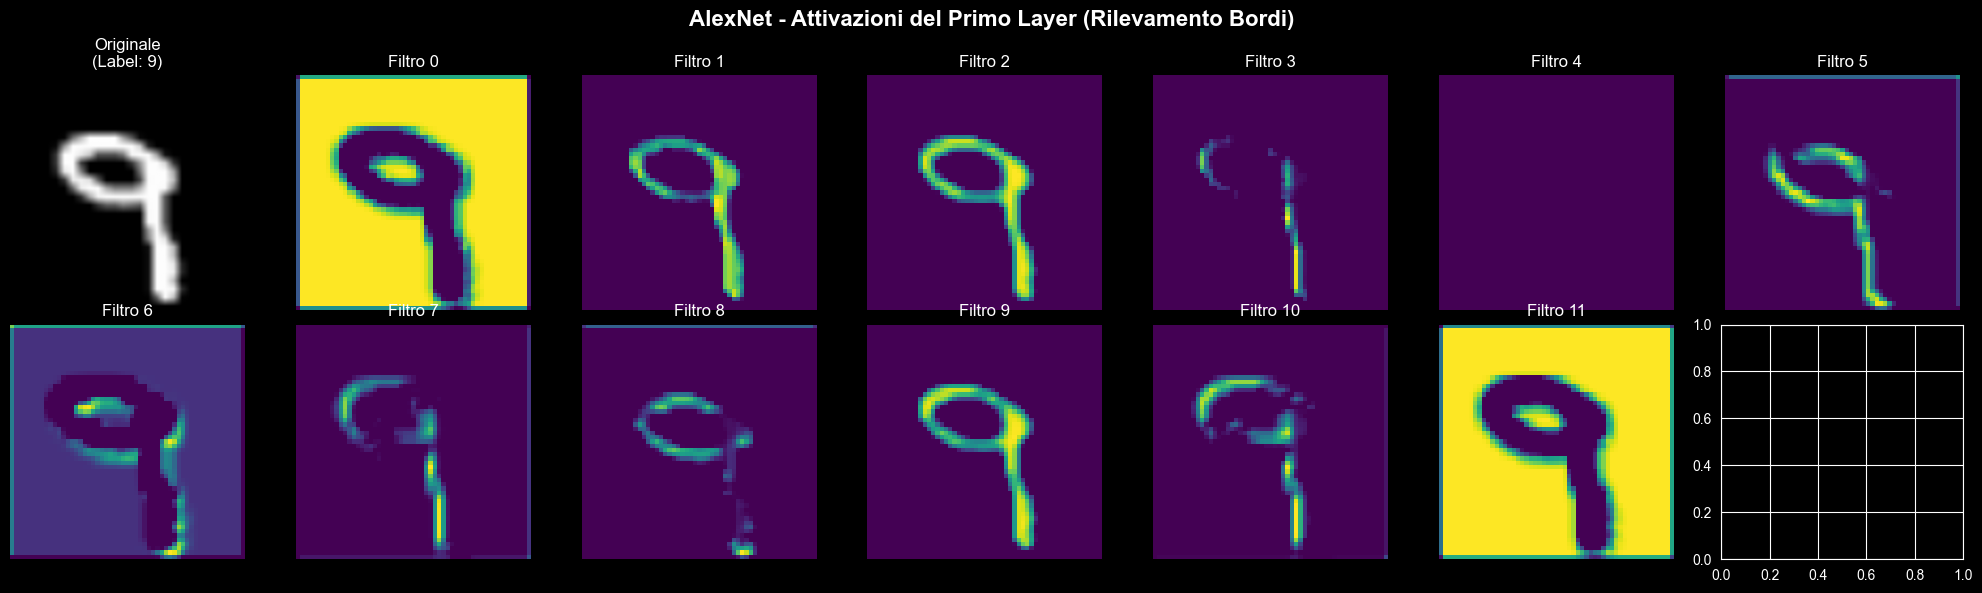

In [15]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualizza_attivazioni_alexnet(model, dataset, device, img_idx=0):
    model.eval()

    # 1. Prendi un'immagine di test e spostala sul device
    img, label = dataset[img_idx]
    img_input = img.unsqueeze(0).to(device)
    # 1. Preparazione immagine per la visualizzazione
    # Da [3, 224, 224] a [224, 224, 3]
    img_vis = img.permute(1, 2, 0).numpy()
    # Denormalizzazione (riporta da [-1, 1] a [0, 1])
    img_vis = img_vis * 0.5 + 0.5
    img_vis = np.clip(img_vis, 0, 1)
    with torch.no_grad():
        # Estraiamo l'output del primo strato (Conv2d + ReLU)
        # Nella nostra AlexNet, features[0] è la Conv e features[1] è la ReLU
        first_layer_conv = model.features[0](img_input)
        first_layer_activation = torch.relu(first_layer_conv)

        # Estraiamo l'output del secondo blocco convoluzionale (opzionale)
        # features[3] è la seconda Conv2d
        second_layer_activation = torch.relu(model.features[3](model.features[2](first_layer_activation)))

    # 2. Visualizzazione del PRIMO LAYER (64 filtri totali, ne mostriamo 12)
    fig, axes = plt.subplots(2, 7, figsize=(20, 6))

    # Immagine Originale
    axes[0, 0].imshow(img_vis.squeeze(), cmap='gray')
    axes[0, 0].set_title(f"Originale\n(Label: {label})")
    axes[0, 0].axis('off')

    # Mostriamo i primi 12 filtri del Layer 1
    for i in range(13):
        if i == 0: continue # Salta il posto dell'originale
        idx = i - 1
        row = i // 7
        col = i % 7
        axes[row, col].imshow(first_layer_activation[0, idx].cpu(), cmap='viridis')
        axes[row, col].set_title(f"Filtro {idx}")
        axes[row, col].axis('off')

    plt.suptitle("AlexNet - Attivazioni del Primo Layer (Rilevamento Bordi)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Esecuzione (assicurati che 'val_subset' sia il dataset corretto)
visualizza_attivazioni_alexnet(model, val_subset, device, img_idx=16)

# Passiamo ora alla resnet e al transfer learning

In [16]:
from torchvision import models

# Trasformazioni per ResNet
transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    # Normalizzazione standard di ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_resnet)

In [17]:
train_size = 50000
val_size = 10000
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Creiamo i DataLoader
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

In [25]:
#Freeziamo tutti i layer tranne gli ultimi 6
# 1. Carichiamo il modello pre-trained
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 10) # Adattiamo subito l'output

# 2. Congeliamo TUTTI i parametri inizialmente
for param in model.parameters():
    param.requires_grad = False

# 3. Sblocchiamo solo gli ultimi blocchi (layer4 e fc)
# layer4 contiene le convoluzioni più astratte, fc è il classificatore
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# Spostiamo sul device
model = model.to(device)

# 4. L'ottimizzatore deve gestire solo i parametri "sbloccati"
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

print("Layer 1-3: CONGELATI (Feature generiche)")
print("Layer  FC: ATTIVI (Specializzazione sulle cifre)")

Layer 1-3: CONGELATI (Feature generiche)
Layer  FC: ATTIVI (Specializzazione sulle cifre)


In [27]:
# Eseguiamo altre 2-3 epoche di fine-tuning. Ci vogliono all'incirca due minuti per epoca
for epoch in range(2):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    val_acc = check_accuracy(val_loader, model, device)
    print(f"Fine-tuning Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Val Acc: {val_acc:.2f}%")

Fine-tuning Epoch 1, Loss: 0.4134, Val Acc: 92.21%
Fine-tuning Epoch 2, Loss: 0.3372, Val Acc: 93.09%
